In [ ]:
!pip install sdv xgboost shap -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 75.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.1/75.1 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.8/206.8 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 86.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 7.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import files

uploaded = files.upload()

In [ ]:
df = pd.read_csv("creditcard.csv")

print("Dataset Loaded Successfully")
print(df.head())

Dataset Loaded Successfully
   Time        V1        V2        V3        V4        V5        V6        V7  \
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1     0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2     1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3     1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4     2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

    

In [ ]:
print("Shape of Dataset:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Shape of Dataset: (93181, 31)

Columns:
Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

Missing Values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       1
V14       1
V15       1
V16       1
V17       1
V18       1
V19       1
V20       1
V21       1
V22       1
V23       1
V24       1
V25       1
V26       1
V27       1
V28       1
Amount    1
Class     1
dtype: int64

Duplicate Rows: 327


In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,93181.000000,93181.000000,93181.000000,93181.000000,93181.000000,93181.000000,93181.000000,93181.000000,93181.000000,93181.000000,...,93180.000000,93180.000000,93180.000000,93180.000000,93180.000000,93180.000000,93180.000000,93180.000000,93180.000000,93180.000000
mean,40720.460405,-0.263002,-0.040780,0.676306,0.163064,-0.280078,0.093917,-0.108816,0.055540,-0.036898,...,-0.029999,-0.107373,-0.037835,0.009540,0.132163,0.026936,0.001515,0.002321,99.030945,0.002286
std,16392.444505,1.869011,1.664308,1.341575,1.355105,1.368687,1.303615,1.225238,1.209672,1.123318,...,0.723135,0.634840,0.640783,0.594557,0.442183,0.495719,0.389447,0.324150,268.350415,0.047757
min,0.000000,-56.407510,-72.715728,-33.680984,-5.172595,-42.147898,-26.160506,-31.764946,-73.216718,-9.283925,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.534330,-9.390980,-9.617915,0.000000,0.000000
25%,32678.000000,-1.028016,-0.605706,0.179018,-0.716783,-0.898708,-0.647692,-0.600859,-0.139122,-0.695859,...,-0.224205,-0.528068,-0.177280,-0.322364,-0.132298,-0.325627,-0.062925,-0.005614,7.600000,0.000000
50%,42848.000000,-0.258489,0.072818,0.756532,0.189117,-0.314928,-0.156536,-0.069893,0.072409,-0.109294,...,-0.057606,-0.082454,-0.049500,0.064890,0.170764,-0.070610,0.009579,0.023267,26.945000,0.000000
75%,53622.000000,1.153021,0.728656,1.381324,1.034477,0.250915,0.487658,0.415870,0.357253,0.576494,...,0.119664,0.309217,0.081457,0.406029,0.420096,0.304235,0.082701,0.076475,89.990000,0.000000
max,64283.000000,1.960497,18.902453,4.226108,16.715537,34.801666,22.529298,36.677268,20.007208,10.392889,...,22.614889,10.503090,18.946734,4.014444,5.541598,3.517346,12.152401,33.847808,19656.530000,1.000000


In [ ]:
print(df["Class"].value_counts())

fraud = df[df["Class"]==1]
normal = df[df["Class"]==0]

print("\nNormal Transactions :", len(normal))
print("Fraud Transactions :", len(fraud))

Class
0.0    92967
1.0      213
Name: count, dtype: int64

Normal Transactions : 92967
Fraud Transactions : 213


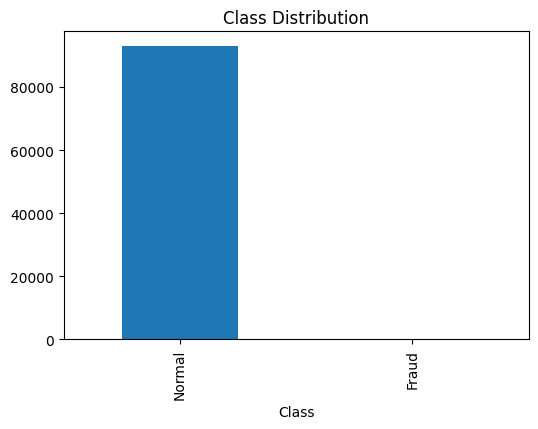

In [ ]:
plt.figure(figsize=(6,4))

df["Class"].value_counts().plot(kind="bar")

plt.xticks([0,1],["Normal","Fraud"])

plt.title("Class Distribution")

plt.show()

In [ ]:
print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       1
V14       1
V15       1
V16       1
V17       1
V18       1
V19       1
V20       1
V21       1
V22       1
V23       1
V24       1
V25       1
V26       1
V27       1
V28       1
Amount    1
Class     1
dtype: int64


In [ ]:
print("Before Removing Duplicates:", df.shape)

df = df.drop_duplicates()

print("After Removing Duplicates:", df.shape)

Before Removing Duplicates: (93181, 31)
After Removing Duplicates: (92854, 31)


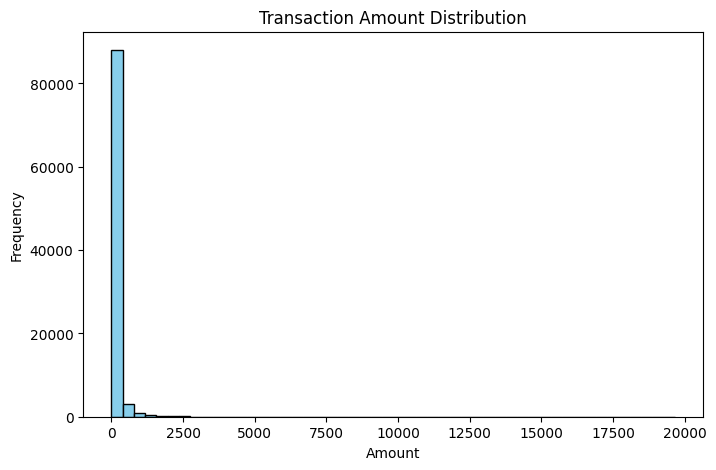

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df['Amount'], bins=50, color='skyblue', edgecolor='black')
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

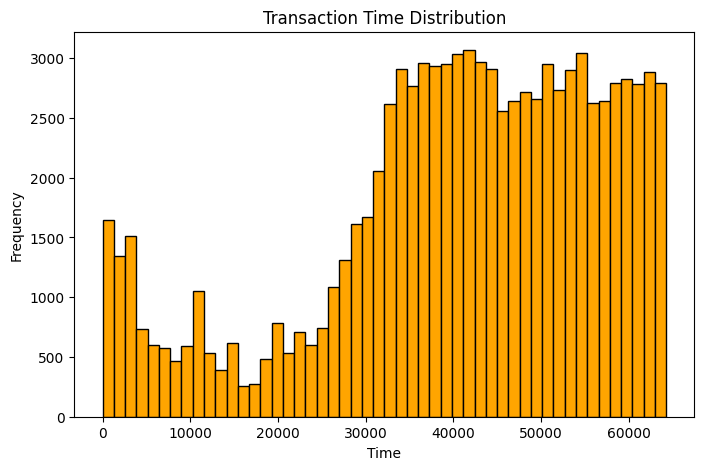

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df['Time'], bins=50, color='orange', edgecolor='black')
plt.title("Transaction Time Distribution")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.show()

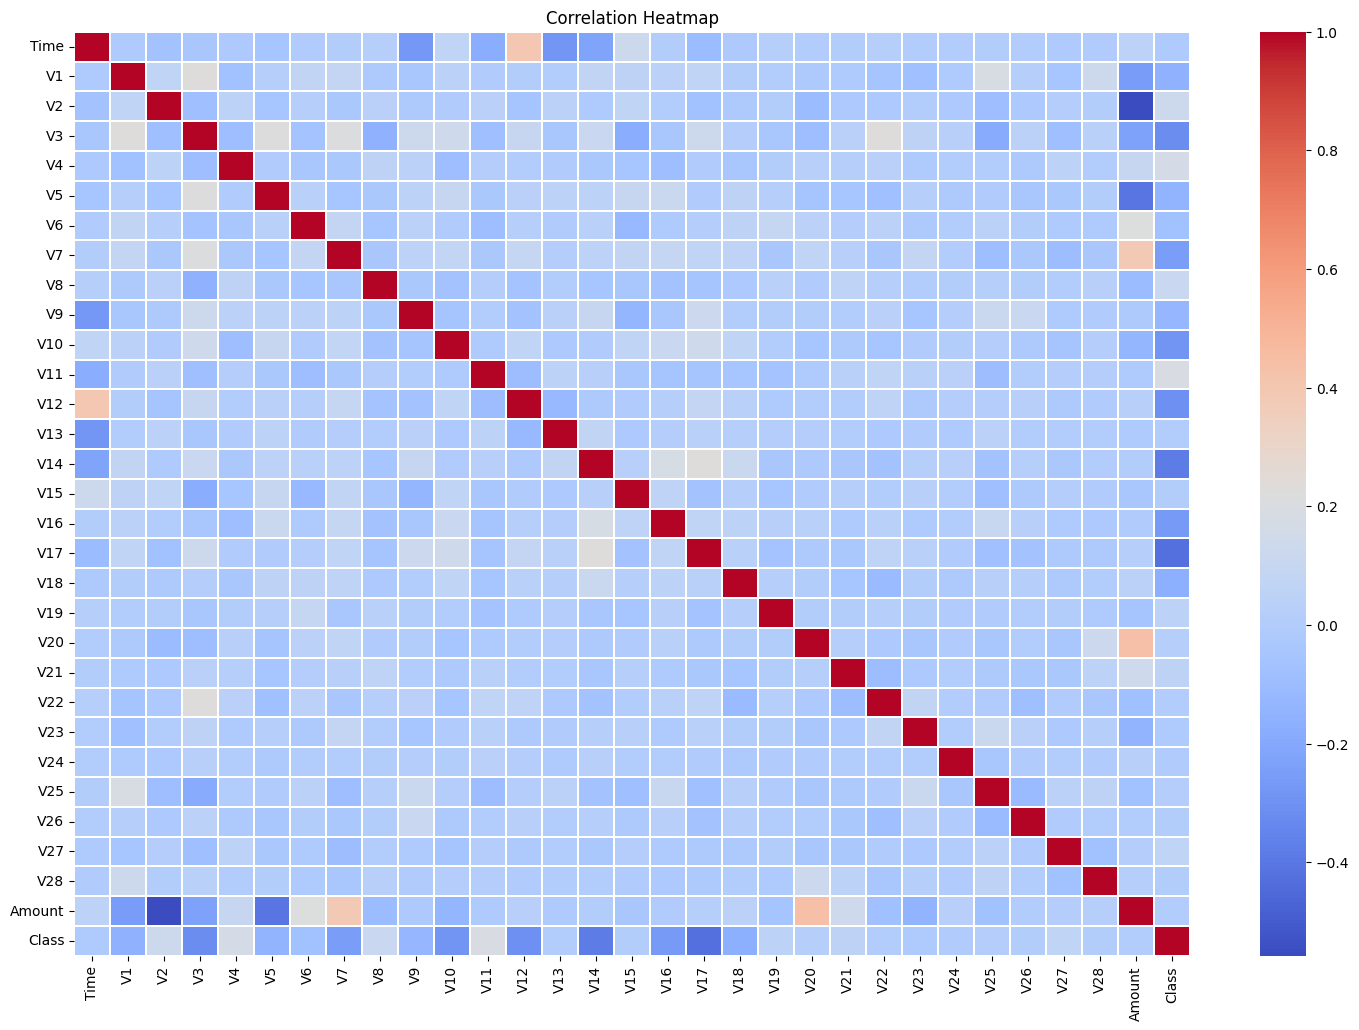

In [ ]:
import seaborn as sns

plt.figure(figsize=(18,12))
sns.heatmap(df.corr(), cmap="coolwarm", linewidths=0.3)
plt.title("Correlation Heatmap")
plt.show()

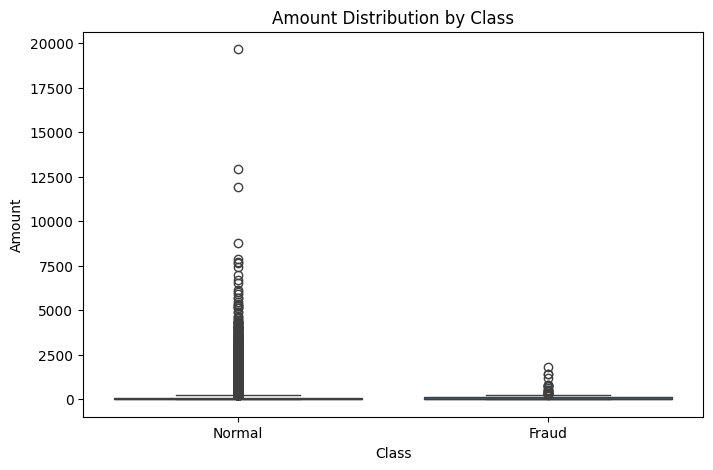

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Class", y="Amount", data=df)

plt.xticks([0,1],["Normal","Fraud"])

plt.title("Amount Distribution by Class")

plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df['scaled_amount'] = scaler.fit_transform(df[['Amount']])

df['scaled_time'] = scaler.fit_transform(df[['Time']])

df.drop(['Amount','Time'], axis=1, inplace=True)

print(df.head())

         V1        V2        V3        V4        V5        V6        V7  \
0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9       V10  ...       V22       V23       V24       V25  \
0  0.098698  0.363787  0.090794  ...  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425 -0.166974  ... -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  0.207643  ...  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024 -0.054952  ...  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  0.753074  ...  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28  Class  scaled_amount  scaled_time  

In [ ]:
fraud_data = df[df['Class']==1]

print("Fraud Data Shape:", fraud_data.shape)

fraud_data.head()

Fraud Data Shape: (213, 31)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,scaled_amount,scaled_time
541,-2.312227,1.951992,-1.609851,3.997906,-0.522188,-1.426545,-2.537387,1.391657,-2.770089,-2.772272,...,-0.035049,-0.465211,0.320198,0.044519,0.177840,0.261145,-0.143276,1.0,-0.369140,-2.460094
623,-3.043541,-3.157307,1.088463,2.288644,1.359805,-1.064823,0.325574,-0.067794,-0.270953,-0.838587,...,0.435477,1.375966,-0.293803,0.279798,-0.145362,-0.252773,0.035764,1.0,1.599624,-2.456067
4920,-2.303350,1.759247,-0.359745,2.330243,-0.821628,-0.075788,0.562320,-0.399147,-0.238253,-1.525412,...,-0.932391,0.172726,-0.087330,-0.156114,-0.542628,0.039566,-0.153029,1.0,0.523801,-2.212653
6108,-4.397974,1.358367,-2.592844,2.679787,-1.128131,-1.706536,-3.496197,-0.248778,-0.247768,-4.801637,...,0.176968,-0.436207,-0.053502,0.252405,-0.657488,-0.827136,0.849573,1.0,-0.149561,-2.058674
6329,1.234235,3.019740,-4.304597,4.732795,3.624201,-1.357746,1.713445,-0.496358,-1.282858,-2.447469,...,-0.704181,-0.656805,-1.632653,1.488901,0.566797,-0.010016,0.146793,1.0,-0.365418,-2.026157


In [ ]:
fraud_data.to_csv("fraud_data.csv", index=False)

print("Fraud Dataset Saved Successfully")

Fraud Dataset Saved Successfully


In [ ]:
fraud = pd.read_csv("fraud_data.csv")

fraud.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,scaled_amount,scaled_time
0,-2.312227,1.951992,-1.609851,3.997906,-0.522188,-1.426545,-2.537387,1.391657,-2.770089,-2.772272,...,-0.035049,-0.465211,0.320198,0.044519,0.177840,0.261145,-0.143276,1.0,-0.369140,-2.460094
1,-3.043541,-3.157307,1.088463,2.288644,1.359805,-1.064823,0.325574,-0.067794,-0.270953,-0.838587,...,0.435477,1.375966,-0.293803,0.279798,-0.145362,-0.252773,0.035764,1.0,1.599624,-2.456067
2,-2.303350,1.759247,-0.359745,2.330243,-0.821628,-0.075788,0.562320,-0.399147,-0.238253,-1.525412,...,-0.932391,0.172726,-0.087330,-0.156114,-0.542628,0.039566,-0.153029,1.0,0.523801,-2.212653
3,-4.397974,1.358367,-2.592844,2.679787,-1.128131,-1.706536,-3.496197,-0.248778,-0.247768,-4.801637,...,0.176968,-0.436207,-0.053502,0.252405,-0.657488,-0.827136,0.849573,1.0,-0.149561,-2.058674
4,1.234235,3.019740,-4.304597,4.732795,3.624201,-1.357746,1.713445,-0.496358,-1.282858,-2.447469,...,-0.704181,-0.656805,-1.632653,1.488901,0.566797,-0.010016,0.146793,1.0,-0.365418,-2.026157


In [ ]:
from google.colab import files

files.download("fraud_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print("="*50)
print("EDA SUMMARY")
print("="*50)

print("Total Transactions :", len(df))
print("Fraud Transactions :", len(fraud_data))
print("Normal Transactions :", len(df)-len(fraud_data))

print("\nMissing Values :", df.isnull().sum().sum())

print("\nDuplicate Rows :", df.duplicated().sum())

print("\nEDA Completed Successfully!")

EDA SUMMARY
Total Transactions : 92854
Fraud Transactions : 213
Normal Transactions : 92641

Missing Values : 18

Duplicate Rows : 0

EDA Completed Successfully!


In [ ]:
import sdv
print(sdv.__version__)

1.37.3


In [ ]:
from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata

In [ ]:
metadata = SingleTableMetadata()

metadata.detect_from_dataframe(data=fraud_data)

metadata

{
    "METADATA_SPEC_VERSION": "SINGLE_TABLE_V1",
    "columns": {
        "V1": {
            "sdtype": "numerical"
        },
        "V2": {
            "sdtype": "numerical"
        },
        "V3": {
            "sdtype": "numerical"
        },
        "V4": {
            "sdtype": "numerical"
        },
        "V5": {
            "sdtype": "numerical"
        },
        "V6": {
            "sdtype": "numerical"
        },
        "V7": {
            "sdtype": "numerical"
        },
        "V8": {
            "sdtype": "numerical"
        },
        "V9": {
            "sdtype": "numerical"
        },
        "V10": {
            "sdtype": "numerical"
        },
        "V11": {
            "sdtype": "numerical"
        },
        "V12": {
            "sdtype": "numerical"
        },
        "V13": {
            "sdtype": "numerical"
        },
        "V14": {
            "sdtype": "numerical"
        },
        "V15": {
            "sdtype": "numerical"
        },
        "V16

In [ ]:
ctgan = CTGANSynthesizer(
    metadata=metadata,
    epochs=100
)

In [ ]:
ctgan.fit(fraud_data)

print("CTGAN Training Completed Successfully!")

CTGAN Training Completed Successfully!


In [ ]:
synthetic_data = ctgan.sample(num_rows=5000)

print("Synthetic Data Shape:", synthetic_data.shape)

synthetic_data.head()

Synthetic Data Shape: (5000, 31)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,scaled_amount,scaled_time
0,-8.741009,2.594943,-10.324794,-0.831427,-0.754834,-1.096500,-1.241739,-3.277535,-2.828721,-12.737242,...,-0.607749,1.891896,0.530356,-2.916922,0.881917,0.081860,-0.172988,1.0,-0.369140,-0.173810
1,1.296231,3.163077,-28.400909,0.805631,2.063301,-1.473339,-4.764988,-2.236238,1.249243,0.907552,...,-0.880886,2.661291,-0.783740,0.023229,0.967434,1.670031,-0.151821,1.0,-0.356712,-1.509128
2,1.296231,4.552817,-0.852324,5.254442,1.146922,-1.383280,-4.594393,-0.533734,-1.317511,-4.916185,...,-1.035057,0.493067,0.795190,0.664583,0.709385,-3.221599,0.304084,1.0,-0.251874,-2.460094
3,0.706296,4.297314,2.041003,2.585462,5.269255,0.674304,0.763873,-0.417853,-3.265152,-0.494841,...,-0.195537,2.661291,0.795190,-0.068540,0.024997,-0.097694,0.031442,1.0,-0.369140,0.484021
4,0.873296,8.023637,-2.244294,0.914074,5.269255,1.732086,-3.674137,4.006155,-5.984022,-0.080851,...,-1.147165,0.178069,-0.127173,1.154390,0.579473,-3.668787,-0.581988,1.0,-0.369140,-1.369029


In [ ]:
synthetic_data.to_csv("synthetic_fraud_data.csv", index=False)

print("Synthetic Data Saved Successfully!")

Synthetic Data Saved Successfully!


In [ ]:
print("Real Fraud Data :", fraud_data.shape)

print("Synthetic Fraud Data :", synthetic_data.shape)

Real Fraud Data : (213, 31)
Synthetic Fraud Data : (5000, 31)


In [ ]:
print("Real Fraud Data Statistics")

display(fraud_data.describe())

print("\nSynthetic Fraud Data Statistics")

display(synthetic_data.describe())

Real Fraud Data Statistics


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,scaled_amount,scaled_time
count,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,...,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,213.0,213.000000,213.000000
mean,-6.244735,4.292771,-8.210525,5.013849,-4.514902,-1.875183,-6.513625,2.843951,-2.980089,-6.343377,...,-0.128955,-0.231495,-0.104869,0.212955,0.096711,0.531091,0.042891,1.0,0.034510,-0.329417
std,7.595270,4.245463,8.210512,2.862557,5.927248,1.591376,6.462615,4.947351,2.470627,4.392014,...,0.804428,1.558583,0.497527,0.915785,0.402806,1.140224,0.582959,0.0,0.901637,1.035192
min,-30.552380,-6.976420,-31.103685,-1.255593,-22.105532,-5.080408,-21.922811,-3.277535,-9.283925,-18.271168,...,-2.288686,-19.254328,-1.632653,-4.781606,-1.055997,-3.908080,-1.869290,1.0,-0.369140,-2.460094
25%,-9.001351,1.443523,-12.788462,2.730668,-7.609909,-2.958431,-11.199975,0.077874,-4.467103,-8.928656,...,-0.630358,-0.521627,-0.425550,-0.236845,-0.222671,0.046627,-0.123391,1.0,-0.365418,-1.200928
50%,-3.218952,3.261585,-5.297446,4.853894,-2.494141,-1.800904,-4.235253,0.889805,-2.752611,-5.699922,...,-0.035049,-0.135707,-0.031393,0.157771,0.056031,0.553143,0.185030,1.0,-0.340818,-0.004233
75%,-1.101847,6.503185,-2.066180,6.456588,-0.461729,-0.768219,-1.621986,3.709210,-1.181743,-3.095094,...,0.440020,0.210692,0.187613,0.697103,0.441044,1.300236,0.402528,1.0,0.002990,0.442332
max,1.296231,16.713389,2.041003,11.927512,5.269255,3.874668,5.431271,20.007208,2.820829,3.245086,...,1.745315,2.661291,0.795190,2.208209,1.179242,3.052358,1.130625,1.0,6.365893,1.425200



Synthetic Fraud Data Statistics


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,scaled_amount,scaled_time
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,...,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0,5000.000000,5000.000000
mean,-2.571911,6.126663,-5.270012,2.194082,-0.485669,-0.300730,-7.754024,-1.090002,0.274679,-3.286350,...,-0.877456,1.182201,0.306902,-0.145769,0.251006,-0.889149,-0.281553,1.0,-0.212379,-1.052053
std,6.249165,5.395395,8.015720,3.013021,6.069594,1.621357,6.035880,2.707310,2.258270,4.923313,...,0.862039,1.040927,0.532964,1.064784,0.416834,1.713792,0.641196,0.0,0.516937,0.954604
min,-30.552380,-6.976420,-31.103685,-1.255593,-22.105532,-5.080408,-21.922811,-3.277535,-9.263457,-18.271168,...,-2.288686,-11.373838,-1.632653,-4.781606,-1.055997,-3.908080,-1.869290,1.0,-0.369140,-2.460094
25%,-3.553497,2.327595,-8.029823,-0.469469,-3.262402,-1.263647,-9.327236,-2.971496,-1.025612,-6.768554,...,-1.429453,0.499146,0.023057,-0.656402,-0.033487,-2.283100,-0.506084,1.0,-0.369140,-1.731175
50%,0.177264,4.727259,-2.918155,1.819815,1.322435,-0.082747,-6.688976,-1.747945,0.687332,-2.562756,...,-0.868691,1.121987,0.457675,-0.116623,0.282178,-0.359025,-0.186078,1.0,-0.369140,-1.120091
75%,1.296231,9.531132,0.945684,4.025091,4.430256,0.847794,-3.898205,-0.176336,2.171165,0.802863,...,-0.304418,2.071920,0.795190,0.476970,0.568431,0.242057,0.129175,1.0,-0.291626,-0.417499
max,1.296231,16.713389,2.041003,11.927512,5.269255,3.874668,5.431271,20.007208,2.820829,3.245086,...,1.745315,2.661291,0.795190,2.208209,1.179242,3.052358,1.130625,1.0,6.365893,1.425200


In [ ]:
from google.colab import files

files.download("synthetic_fraud_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print("="*60)

print("CTGAN MODEL SUMMARY")

print("="*60)

print("Real Fraud Samples :", len(fraud_data))

print("Synthetic Samples Generated :", len(synthetic_data))

print("\nGenerative AI Successfully Created Synthetic Fraud Transactions!")

print("="*60)

CTGAN MODEL SUMMARY
Real Fraud Samples : 213
Synthetic Samples Generated : 5000

Generative AI Successfully Created Synthetic Fraud Transactions!


In [ ]:
# Combine original dataset with synthetic fraud data
augmented_data = pd.concat([df, synthetic_data], ignore_index=True)

print("Original Dataset Shape :", df.shape)
print("Synthetic Dataset Shape :", synthetic_data.shape)
print("Augmented Dataset Shape :", augmented_data.shape)

Original Dataset Shape : (92854, 31)
Synthetic Dataset Shape : (5000, 31)
Augmented Dataset Shape : (97854, 31)


In [ ]:
# Reset index
df = df.reset_index(drop=True)
synthetic_data = synthetic_data.reset_index(drop=True)

# Remove any rows where Class is missing
df = df.dropna(subset=["Class"])
synthetic_data = synthetic_data.dropna(subset=["Class"])

# Convert Class to integer
df["Class"] = df["Class"].astype(int)
synthetic_data["Class"] = synthetic_data["Class"].astype(int)

print("Original Dataset Shape:", df.shape)
print("Synthetic Dataset Shape:", synthetic_data.shape)

Original Dataset Shape: (92853, 31)
Synthetic Dataset Shape: (5000, 31)


In [ ]:
augmented_data = pd.concat([df, synthetic_data], ignore_index=True)

print("Augmented Dataset Shape:", augmented_data.shape)

Augmented Dataset Shape: (97853, 31)


In [ ]:
# Remove any missing values
augmented_data = augmented_data.dropna().reset_index(drop=True)

print("Missing Values:")
print(augmented_data.isnull().sum().sum())

print("Duplicate Rows:", augmented_data.duplicated().sum())

Missing Values:
0
Duplicate Rows: 0


In [ ]:
print(augmented_data["Class"].value_counts())

Class
0    92640
1     5213
Name: count, dtype: int64


In [ ]:
X = augmented_data.drop(columns=["Class"])
y = augmented_data["Class"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

print("NaN in X:", X.isnull().sum().sum())
print("NaN in y:", y.isnull().sum())

X Shape: (97853, 30)
y Shape: (97853,)
NaN in X: 0
NaN in y: 0


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (78282, 30)
Testing Shape: (19571, 30)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [ ]:
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:,1]

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Accuracy :", round(accuracy_score(y_test, y_pred),4))
print("Precision :", round(precision_score(y_test, y_pred),4))
print("Recall :", round(recall_score(y_test, y_pred),4))
print("F1 Score :", round(f1_score(y_test, y_pred),4))
print("ROC AUC :", round(roc_auc_score(y_test, y_prob),4))

Accuracy : 0.9994
Precision : 0.9952
Recall : 0.9942
F1 Score : 0.9947
ROC AUC : 0.998


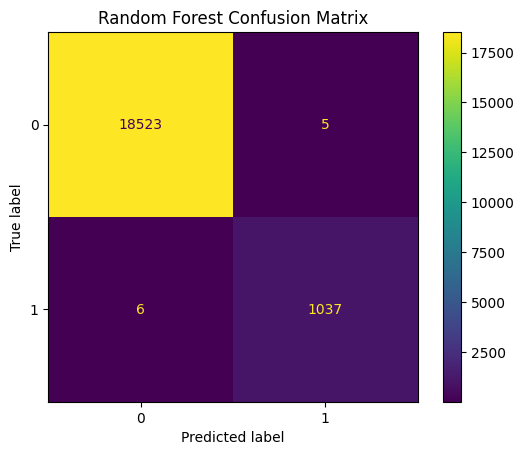

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)

plt.title("Random Forest Confusion Matrix")
plt.show()

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

print("XGBoost Model Trained Successfully!")

XGBoost Model Trained Successfully!


In [ ]:
xgb_pred = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)[:,1]

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Accuracy :", round(accuracy_score(y_test, xgb_pred),4))
print("Precision :", round(precision_score(y_test, xgb_pred),4))
print("Recall :", round(recall_score(y_test, xgb_pred),4))
print("F1 Score :", round(f1_score(y_test, xgb_pred),4))
print("ROC AUC :", round(roc_auc_score(y_test, xgb_prob),4))

Accuracy : 0.9996
Precision : 1.0
Recall : 0.9933
F1 Score : 0.9966
ROC AUC : 0.9999


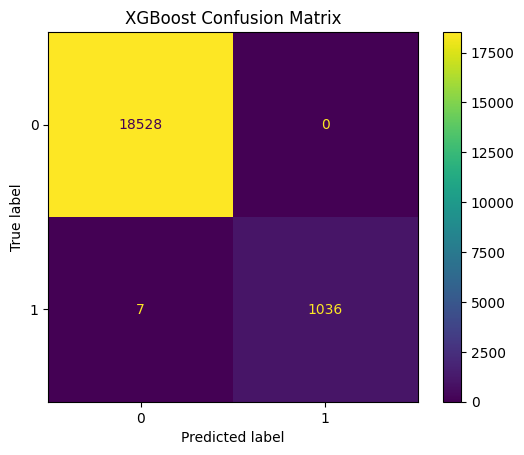

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(xgb, X_test, y_test)

plt.title("XGBoost Confusion Matrix")
plt.show()

In [ ]:
import pandas as pd

comparison = pd.DataFrame({
    "Model":["Random Forest","XGBoost"],
    "Accuracy":[accuracy_score(y_test,y_pred),accuracy_score(y_test,xgb_pred)],
    "Precision":[precision_score(y_test,y_pred),precision_score(y_test,xgb_pred)],
    "Recall":[recall_score(y_test,y_pred),recall_score(y_test,xgb_pred)],
    "F1 Score":[f1_score(y_test,y_pred),f1_score(y_test,xgb_pred)],
    "ROC AUC":[roc_auc_score(y_test,y_prob),roc_auc_score(y_test,xgb_prob)]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Random Forest,0.999438,0.995202,0.994247,0.994724,0.998014
1,XGBoost,0.999642,1.000000,0.993289,0.996633,0.999898


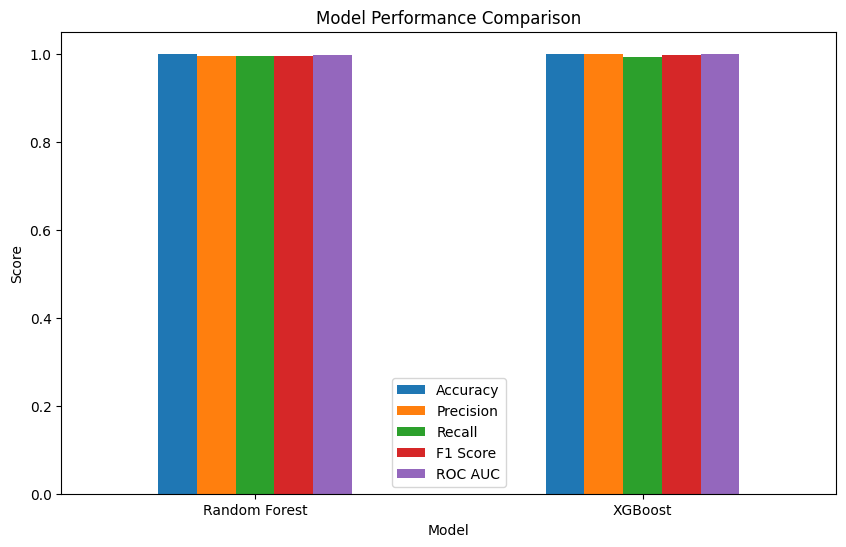

In [ ]:
comparison.set_index("Model").plot(kind="bar", figsize=(10,6))

plt.title("Model Performance Comparison")

plt.ylabel("Score")

plt.xticks(rotation=0)

plt.show()

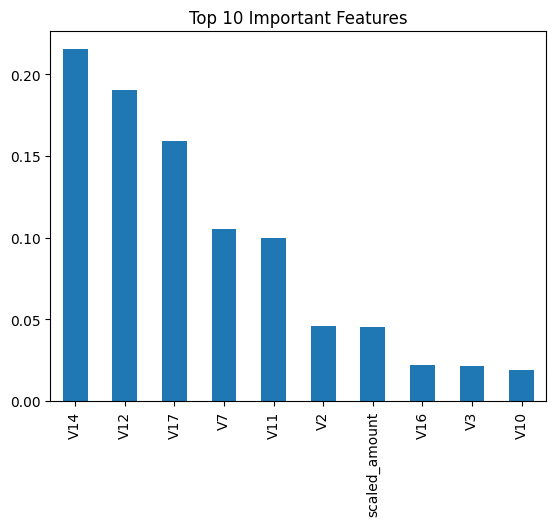

In [ ]:
import pandas as pd

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance.head(10).plot(kind="bar")

plt.title("Top 10 Important Features")

plt.show()

In [ ]:
import joblib

joblib.dump(rf,"fraud_detection_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [ ]:
from google.colab import files

files.download("fraud_detection_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print("="*60)

print("PROJECT COMPLETED SUCCESSFULLY")

print("="*60)

print("Dataset Loaded")

print("EDA Completed")

print("CTGAN Trained")

print("Synthetic Fraud Generated")

print("Augmented Dataset Created")

print("Random Forest Trained")

print("XGBoost Trained")

print("Models Evaluated")

print("Model Saved")

print("="*60)

PROJECT COMPLETED SUCCESSFULLY
Dataset Loaded
EDA Completed
CTGAN Trained
Synthetic Fraud Generated
Augmented Dataset Created
Random Forest Trained
XGBoost Trained
Models Evaluated
Model Saved


In [ ]:
synthetic_data.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,scaled_amount,scaled_time
0,-8.741009,2.594943,-10.324794,-0.831427,-0.754834,-1.096500,-1.241739,-3.277535,-2.828721,-12.737242,...,-0.607749,1.891896,0.530356,-2.916922,0.881917,0.081860,-0.172988,1,-0.369140,-0.173810
1,1.296231,3.163077,-28.400909,0.805631,2.063301,-1.473339,-4.764988,-2.236238,1.249243,0.907552,...,-0.880886,2.661291,-0.783740,0.023229,0.967434,1.670031,-0.151821,1,-0.356712,-1.509128
2,1.296231,4.552817,-0.852324,5.254442,1.146922,-1.383280,-4.594393,-0.533734,-1.317511,-4.916185,...,-1.035057,0.493067,0.795190,0.664583,0.709385,-3.221599,0.304084,1,-0.251874,-2.460094
3,0.706296,4.297314,2.041003,2.585462,5.269255,0.674304,0.763873,-0.417853,-3.265152,-0.494841,...,-0.195537,2.661291,0.795190,-0.068540,0.024997,-0.097694,0.031442,1,-0.369140,0.484021
4,0.873296,8.023637,-2.244294,0.914074,5.269255,1.732086,-3.674137,4.006155,-5.984022,-0.080851,...,-1.147165,0.178069,-0.127173,1.154390,0.579473,-3.668787,-0.581988,1,-0.369140,-1.369029


In [ ]:
print("Original Fraud Data")
fraud_data.head()

Original Fraud Data


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,scaled_amount,scaled_time
541,-2.312227,1.951992,-1.609851,3.997906,-0.522188,-1.426545,-2.537387,1.391657,-2.770089,-2.772272,...,-0.035049,-0.465211,0.320198,0.044519,0.177840,0.261145,-0.143276,1.0,-0.369140,-2.460094
623,-3.043541,-3.157307,1.088463,2.288644,1.359805,-1.064823,0.325574,-0.067794,-0.270953,-0.838587,...,0.435477,1.375966,-0.293803,0.279798,-0.145362,-0.252773,0.035764,1.0,1.599624,-2.456067
4920,-2.303350,1.759247,-0.359745,2.330243,-0.821628,-0.075788,0.562320,-0.399147,-0.238253,-1.525412,...,-0.932391,0.172726,-0.087330,-0.156114,-0.542628,0.039566,-0.153029,1.0,0.523801,-2.212653
6108,-4.397974,1.358367,-2.592844,2.679787,-1.128131,-1.706536,-3.496197,-0.248778,-0.247768,-4.801637,...,0.176968,-0.436207,-0.053502,0.252405,-0.657488,-0.827136,0.849573,1.0,-0.149561,-2.058674
6329,1.234235,3.019740,-4.304597,4.732795,3.624201,-1.357746,1.713445,-0.496358,-1.282858,-2.447469,...,-0.704181,-0.656805,-1.632653,1.488901,0.566797,-0.010016,0.146793,1.0,-0.365418,-2.026157


In [ ]:
print("Synthetic Fraud Data")
synthetic_data.head()

Synthetic Fraud Data


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,scaled_amount,scaled_time
0,-8.741009,2.594943,-10.324794,-0.831427,-0.754834,-1.096500,-1.241739,-3.277535,-2.828721,-12.737242,...,-0.607749,1.891896,0.530356,-2.916922,0.881917,0.081860,-0.172988,1,-0.369140,-0.173810
1,1.296231,3.163077,-28.400909,0.805631,2.063301,-1.473339,-4.764988,-2.236238,1.249243,0.907552,...,-0.880886,2.661291,-0.783740,0.023229,0.967434,1.670031,-0.151821,1,-0.356712,-1.509128
2,1.296231,4.552817,-0.852324,5.254442,1.146922,-1.383280,-4.594393,-0.533734,-1.317511,-4.916185,...,-1.035057,0.493067,0.795190,0.664583,0.709385,-3.221599,0.304084,1,-0.251874,-2.460094
3,0.706296,4.297314,2.041003,2.585462,5.269255,0.674304,0.763873,-0.417853,-3.265152,-0.494841,...,-0.195537,2.661291,0.795190,-0.068540,0.024997,-0.097694,0.031442,1,-0.369140,0.484021
4,0.873296,8.023637,-2.244294,0.914074,5.269255,1.732086,-3.674137,4.006155,-5.984022,-0.080851,...,-1.147165,0.178069,-0.127173,1.154390,0.579473,-3.668787,-0.581988,1,-0.369140,-1.369029
